Notebook illustrating how the results of the paper were obtained. We only consider data from ILL11 for 2018. 

Data can be downloaded from: https://doi.org/10.12686/SED/NETWORKS/XP

In [1]:
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load

from datamod.loading_utils import preproc_flow_annotations
from datamod.trigger_utils import stream_trigger_detections
from isolation_forest.utils import train_if, compute_scores, create_if_stream
from metrics.utils import iou, est_thresholds

C:\Users\franc\AppData\Local\Temp\ipykernel_16884\246795921.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


First we train an isolation forest to the miniseed files contained in the folder "../data/XP/2018/ILL11/HHZ.D".

Note that the suffixes contain the day of the year, which we use to sort the files.

In [2]:
folder = "../data/XP/2018/ILL11/HHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

Now we train the isolation forest. This will take a couple of minutes.

In [3]:
try:
    if_mod = load("../output/if_models/ILL11.joblib")

except (FileNotFoundError, OSError):
    if_mod = train_if(stream_paths)
    dump(if_mod, "../output/if_models/ILL11.joblib")

Next we run the trained isolation forest over the training and/or testing period and extract time series of the anomaly scores.

Note. The miniseed files we worked with correspond to a given day. When we extract sliding windows, there can be a small amount of the waveform towards the end of the day that is not accessed, because it is not sufficiently long to form a full window. In such cases the waveform of the next day (if available) is appended to this residual waveform.

The function below takes a few minutes to run if the scores have not been stored.


In [4]:
try:
    scores_df = pd.read_csv("../output/if_scores/ILL11_anomaly_scores.csv", index_col=0)
    # The conversion to UTCDateTime takes  few seconds
    scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

except (FileNotFoundError, OSError):
    scores_df = compute_scores(stream_paths, if_mod)
    scores_df.to_csv("../output/if_scores/ILL11_anomaly_scores.csv")

The scores_df dataframe is then converted into an obspy stream. Takes a few seconds for the conversion.

In [5]:
if_st = create_if_stream(scores_df, station="ILL11", sr=0.02, network="XP")

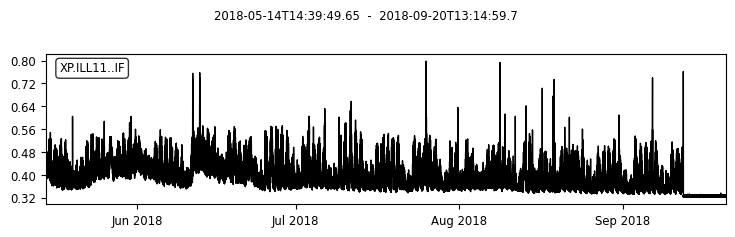

In [6]:
if_st.plot()
plt.show()

Now that we have the isolation forest obspy stream we need to calibrate the onset- and offset thresholds of the IF trigger. For this we only consider days with a debris-flow recorded with high confidence.

We load the catalog and extract the annotations for ILL11 for 2018. We have 3 high confidence debris-flows.

In [7]:
flows = preproc_flow_annotations(pd.read_csv("../catalogues/flow_catalogue.csv"))
flows = flows[flows["station"] == "ILL11"].reset_index(drop=True)
flows = flows[flows["stop"] < obspy.UTCDateTime("2018-12-31T23:59:59")].reset_index(
    drop=True
)

high_conf_flows = flows[flows["confidence"] == 1.0].reset_index(drop=True)
lower_conf_flows = flows[flows["confidence"] != 1.0].reset_index(drop=True)

print(high_conf_flows.head())

  station channel                        start                         stop  \
0   ILL11     HHZ  2018-06-12T19:05:00.000000Z  2018-06-12T20:16:00.000000Z   
1   ILL11     HHZ  2018-07-25T17:01:00.000000Z  2018-07-25T17:39:00.000000Z   
2   ILL11     HHZ  2018-08-08T17:56:00.000000Z  2018-08-08T18:21:00.000000Z   

   confidence Notes  
0         1.0   NaN  
1         1.0   NaN  
2         1.0   NaN  


Now we extract the spays spanning the high confidence annotations.

In [8]:
st = obspy.Stream()
for i in range(high_conf_flows.shape[0]):
    dt = high_conf_flows["start"].iloc[i]
    start = obspy.UTCDateTime(f"{dt.date}T00:00:00")
    dt = high_conf_flows["stop"].iloc[i]
    end = obspy.UTCDateTime(f"{dt.date}T23:59:59.999999")

    st += if_st.copy().trim(start, end)

Over these extracted days, we select the onset and offset threshold maximizing the IOU metric. 

Note. We do not allow onset < offset.

In [9]:
onset_grid = np.array([0.55, 0.60, 0.65, 0.70])
offset_grid = np.array([0.50, 0.55, 0.60, 0.65])
iou_table = np.zeros([len(onset_grid), len(offset_grid)])

In [10]:
for i in range(onset_grid.shape[0]):
    for j in range(offset_grid.shape[0]):
        if onset_grid[i] < offset_grid[j]:
            continue

        detections = stream_trigger_detections(st, onset_grid[i], offset_grid[j])
        inter, union, _ = iou(detections, high_conf_flows)
        iou_table[i, j] = inter[-1] / union[-1]

In [11]:
max_idx = np.unravel_index(np.argmax(iou_table), iou_table.shape)
onset_thres, offset_thres = onset_grid[max_idx[0]], offset_grid[max_idx[1]]
print(onset_thres, offset_thres, np.max(iou_table))

0.65 0.65 0.5486531655441271


Now that we have calibrated the trigger, we run it over the entirety of 2018.

In [12]:
if_detections = stream_trigger_detections(if_st, onset_thres, offset_thres)
if_detections.to_csv("../output/if_detections/ILL11.csv")
print(if_detections)

                          start                         stop  anomaly_scores
0   2018-07-25T17:04:05.690000Z  2018-07-25T18:02:25.690000Z        0.798512
1   2018-08-08T17:55:45.690000Z  2018-08-08T18:50:45.690000Z        0.793445
2   2018-09-12T12:15:45.690000Z  2018-09-12T12:19:55.690000Z        0.762065
3   2018-06-12T19:10:45.690000Z  2018-06-12T19:52:25.690000Z        0.757814
4   2018-06-11T11:33:15.690000Z  2018-06-11T12:05:45.690000Z        0.755523
5   2018-09-06T16:08:15.690000Z  2018-09-06T16:09:55.690000Z        0.740336
6   2018-08-19T00:38:15.690000Z  2018-08-19T00:43:15.690000Z        0.734453
7   2018-09-06T16:09:55.690000Z  2018-09-06T16:12:25.690000Z        0.706716
8   2018-08-16T18:20:45.690000Z  2018-08-16T18:24:05.690000Z        0.703260
9   2018-06-11T12:06:35.690000Z  2018-06-11T12:14:05.690000Z        0.697790
10  2018-05-14T16:00:25.610000Z  2018-05-14T16:02:05.610000Z        0.695074
11  2018-08-18T18:30:45.690000Z  2018-08-18T18:32:25.690000Z        0.675833

In [13]:
_, min_len, score_thres = est_thresholds(if_detections, high_conf_flows, mode="lower")

In [17]:
final_detections = if_detections.copy()

start_times = np.array([pd.to_datetime(str(i)) for i in final_detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in final_detections["stop"]])

det_lens = np.array([i.total_seconds() for i in end_times - start_times])
final_detections = final_detections.assign(det_lens=det_lens)
final_detections = final_detections[
    (final_detections["anomaly_scores"] > score_thres)
    & (final_detections["det_lens"] > min_len)
]

final_detections.head()

,start,stop,anomaly_scores,det_lens
0,2018-07-25T17:04:05.690000Z,2018-07-25T18:02:25.690000Z,0.798512,3500.0
1,2018-08-08T17:55:45.690000Z,2018-08-08T18:50:45.690000Z,0.793445,3300.0
3,2018-06-12T19:10:45.690000Z,2018-06-12T19:52:25.690000Z,0.757814,2500.0
